# Data Analyst Professional Practical Exam Submission

**You can use any tool that you want to do your analysis and create visualizations. Use this template to write up your summary for submission.**

You can use any markdown formatting you wish. If you are not familiar with Markdown, read the [Markdown Guide](https://s3.amazonaws.com/talent-assets.datacamp.com/Markdown+Guide.pdf) before you start.


## 📝 Task List

Your written report should include written text summaries and graphics of the following:
- Data validation:   
  - Describe validation and cleaning steps for every column in the data 
- Exploratory Analysis:  
  - Include two different graphics showing single variables only to demonstrate the characteristics of data  
  - Include at least one graphic showing two or more variables to represent the relationship between features
  - Describe your findings
- Definition of a metric for the business to monitor  
  - How should the business use the metric to monitor the business problem
  - Can you estimate initial value(s) for the metric based on the current data
- Final summary including recommendations that the business should undertake

*Start writing report here..*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load all three datasets
df  = pd.read_csv('da_fitly_account_info.csv')      # Account info
df2 = pd.read_csv('da_fitly_customer_support.csv')  # Customer support tickets
df3 = pd.read_csv('da_fitly_user_activity.csv')     # User activity events

print(f"Account Info:      {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Customer Support:  {df2.shape[0]:,} rows × {df2.shape[1]} columns")
print(f"User Activity:     {df3.shape[0]:,} rows × {df3.shape[1]} columns")

Account Info:      400 rows × 6 columns
Customer Support:  918 rows × 7 columns
User Activity:     445 rows × 3 columns


2. Data Validation

The datasets come from different teams and have not been pre-validated. Each column is examined below for nulls, incorrect types, invalid categories, and duplicates. All decisions are documented.

2.1 Account Info

In [4]:
print("=== Account Info: Shape & Types ===")
print(df.info())

=== Account Info: Shape & Types ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   customer_id      400 non-null    object
 1   email            400 non-null    object
 2   state            400 non-null    object
 3   plan             400 non-null    object
 4   plan_list_price  400 non-null    int64 
 5   churn_status     114 non-null    object
dtypes: int64(1), object(5)
memory usage: 18.9+ KB
None


In [5]:
# customer_id: check for duplicates and nulls
print("Null customer_ids:", df['customer_id'].isnull().sum())
print("Duplicate customer_ids:", df['customer_id'].duplicated().sum())
print("Unique customers:", df['customer_id'].nunique())

Null customer_ids: 0
Duplicate customer_ids: 0
Unique customers: 400


In [6]:
# email: check for duplicates and nulls
print("Null emails:", df['email'].isnull().sum())
print("Duplicate emails:", df['email'].duplicated().sum())

Null emails: 0
Duplicate emails: 0


In [7]:
# state: check valid US states
print("Unique states:", df['state'].nunique())
print(sorted(df['state'].unique()))

Unique states: 50
['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']


In [8]:
# plan: check categories
print("Plan distribution:")
print(df['plan'].value_counts())

Plan distribution:
Basic         118
Free          105
Enterprise     92
Pro            85
Name: plan, dtype: int64


In [9]:
# plan_list_price: check range per plan
print("Price range per plan:")
df.groupby('plan')['plan_list_price'].describe().round(2)

Price range per plan:


,count,mean,std,min,25%,50%,75%,max
plan,,,,,,,,
Basic,118.0,19.87,5.91,10.0,15.0,20.0,24.0,30.0
Enterprise,92.0,116.01,20.53,81.0,96.5,119.0,134.0,148.0
Free,105.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0
Pro,85.0,53.74,14.60,32.0,42.0,53.0,64.0,80.0


In [10]:
# churn_status: check nulls and values BEFORE cleaning
print("churn_status value counts (including nulls):")
print(df['churn_status'].value_counts(dropna=False))
print()
print("DECISION: 286 NaN values represent active subscribers.")
print("The column only explicitly labels churned users as 'Y'.")
print("Filling NaN with 'N' (not churned).")

churn_status value counts (including nulls):
NaN    286
Y      114
Name: churn_status, dtype: int64

DECISION: 286 NaN values represent active subscribers.
The column only explicitly labels churned users as 'Y'.
Filling NaN with 'N' (not churned).


In [11]:
# Apply fix: fill NaN churn_status as 'N'
df['churn_status'] = df['churn_status'].fillna('N')
df['churn'] = df['churn_status']  # working copy

print("After cleaning:")
print(df['churn'].value_counts())
print(f"\nOverall churn rate: {(df['churn']=='Y').mean()*100:.1f}%")

After cleaning:
N    286
Y    114
Name: churn, dtype: int64

Overall churn rate: 28.5%


 2.2 Customer Support

In [12]:
print("=== Customer Support: Shape & Types ===")
print(df2.info())

=== Customer Support: Shape & Types ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ticket_time            918 non-null    object 
 1   user_id                918 non-null    int64  
 2   channel                918 non-null    object 
 3   topic                  918 non-null    object 
 4   resolution_time_hours  918 non-null    float64
 5   state                  918 non-null    int64  
 6   comments               46 non-null     object 
dtypes: float64(1), int64(2), object(4)
memory usage: 50.3+ KB
None


In [13]:
# ticket_time: stored as string — convert to datetime
print("dtype before:", df2['ticket_time'].dtype)
df2['ticket_time'] = pd.to_datetime(df2['ticket_time'])
print("dtype after: ", df2['ticket_time'].dtype)
print("Date range:", df2['ticket_time'].min(), "to", df2['ticket_time'].max())

dtype before: object
dtype after:  datetime64[ns]
Date range: 2025-06-05 15:32:33.005817 to 2025-12-01 22:01:58.485299


In [14]:
# channel: check categories
print("Channel value counts:")
print(df2['channel'].value_counts(dropna=False))

Channel value counts:
email    298
chat     294
phone    287
-         39
Name: channel, dtype: int64


In [15]:
# Fix: replace '-' with 'Unknown'
df2['channel'] = df2['channel'].replace('-', 'Unknown')
print("After fix:")
print(df2['channel'].value_counts())

After fix:
email      298
chat       294
phone      287
Unknown     39
Name: channel, dtype: int64


In [16]:
# topic: check categories
print("Topic value counts:")
print(df2['topic'].value_counts())

Topic value counts:
billing      239
other        228
technical    226
account      225
Name: topic, dtype: int64


In [17]:
# resolution_time_hours: check range
print("Resolution time statistics:")
print(df2['resolution_time_hours'].describe().round(2))
print("\nNegative values:", (df2['resolution_time_hours'] < 0).sum())

Resolution time statistics:
count    918.00
mean      10.39
std        7.08
min        0.52
25%        5.11
50%        9.04
75%       13.14
max       32.46
Name: resolution_time_hours, dtype: float64

Negative values: 0


In [ ]:
# state (resolved flag): binary check
print("State (resolved flag) values:")
print(df2['state'].value_counts())

In [18]:
# comments: check nulls
print("Null comments:", df2['comments'].isnull().sum(), "out of", len(df2))
df2['comments'] = df2['comments'].fillna('No Comment')

Null comments: 872 out of 918


2.3 User Activity

In [19]:
print("=== User Activity: Shape & Types ===")
print(df3.info())

=== User Activity: Shape & Types ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445 entries, 0 to 444
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   event_time  445 non-null    object
 1   user_id     445 non-null    int64 
 2   event_type  445 non-null    object
dtypes: int64(1), object(2)
memory usage: 10.6+ KB
None


In [20]:
# Check nulls
print("Null values per column:")
print(df3.isnull().sum())
print("\nDuplicate rows:", df3.duplicated().sum())

Null values per column:
event_time    0
user_id       0
event_type    0
dtype: int64

Duplicate rows: 0


In [21]:
# event_time: convert to datetime
df3['event_time'] = pd.to_datetime(df3['event_time'])
print("Date range:", df3['event_time'].min(), "to", df3['event_time'].max())

Date range: 2025-06-05 10:14:53.039663 to 2025-12-01 21:12:13.342817


In [25]:
# event_type: check categories
print("Event type distribution:")
print(df3['event_type'].value_counts())

print(f"\nUnique users with any activity: {df3['user_id'].nunique()} out of 400 total subscribers")
print("Note: 155 users have no activity records — treated as 0 events in analysis.")

Event type distribution:
read_article     125
watch_video      120
track_workout    108
share_workout     92
Name: event_type, dtype: int64

Unique users with any activity: 246 out of 400 total subscribers
Note: 155 users have no activity records — treated as 0 events in analysis.


2.4 Prepare Analysis Dataset

In [26]:
# Convert customer_id to numeric to match user_id in other tables
df['user_id'] = df['customer_id'].str.replace('C', '').astype(int)

# Build engagement features per user
activity_per_user = (
    df3.groupby('user_id')
    .size()
    .reset_index(name='activity_count')
)

# Build support features per user
tickets_per_user = (
    df2.groupby('user_id')
    .size()
    .reset_index(name='ticket_count')
)

resolution_per_user = (
    df2.groupby('user_id')['resolution_time_hours']
    .mean()
    .reset_index(name='avg_resolution_time')
)

# Merge into one analysis dataframe
analysis = df.merge(activity_per_user, on='user_id', how='left')
analysis = analysis.merge(tickets_per_user, on='user_id', how='left')
analysis = analysis.merge(resolution_per_user, on='user_id', how='left')

# Fill missing values (users with no activity / no tickets)
analysis['activity_count']      = analysis['activity_count'].fillna(0)
analysis['ticket_count']        = analysis['ticket_count'].fillna(0)
analysis['avg_resolution_time'] = analysis['avg_resolution_time'].fillna(0)

print("Analysis dataset shape:", analysis.shape)
analysis[['customer_id', 'plan', 'churn', 'activity_count', 'ticket_count', 'avg_resolution_time']].head(10)

Analysis dataset shape: (400, 11)


,customer_id,plan,churn,activity_count,ticket_count,avg_resolution_time
0,C10000,Enterprise,Y,3.0,3.0,21.446667
1,C10001,Basic,Y,1.0,4.0,17.542500
2,C10002,Basic,N,1.0,3.0,6.433333
3,C10003,Free,N,1.0,1.0,2.190000
4,C10004,Enterprise,N,4.0,4.0,8.542500
5,C10005,Enterprise,N,1.0,2.0,7.815000
6,C10006,Basic,N,0.0,2.0,6.860000
7,C10007,Basic,Y,0.0,3.0,25.166667
8,C10008,Enterprise,N,2.0,1.0,4.580000
9,C10009,Free,N,4.0,3.0,8.273333


3. Exploratory Data Analysis

The following section analyses churn patterns across engagement, support activity, and subscription plan type.

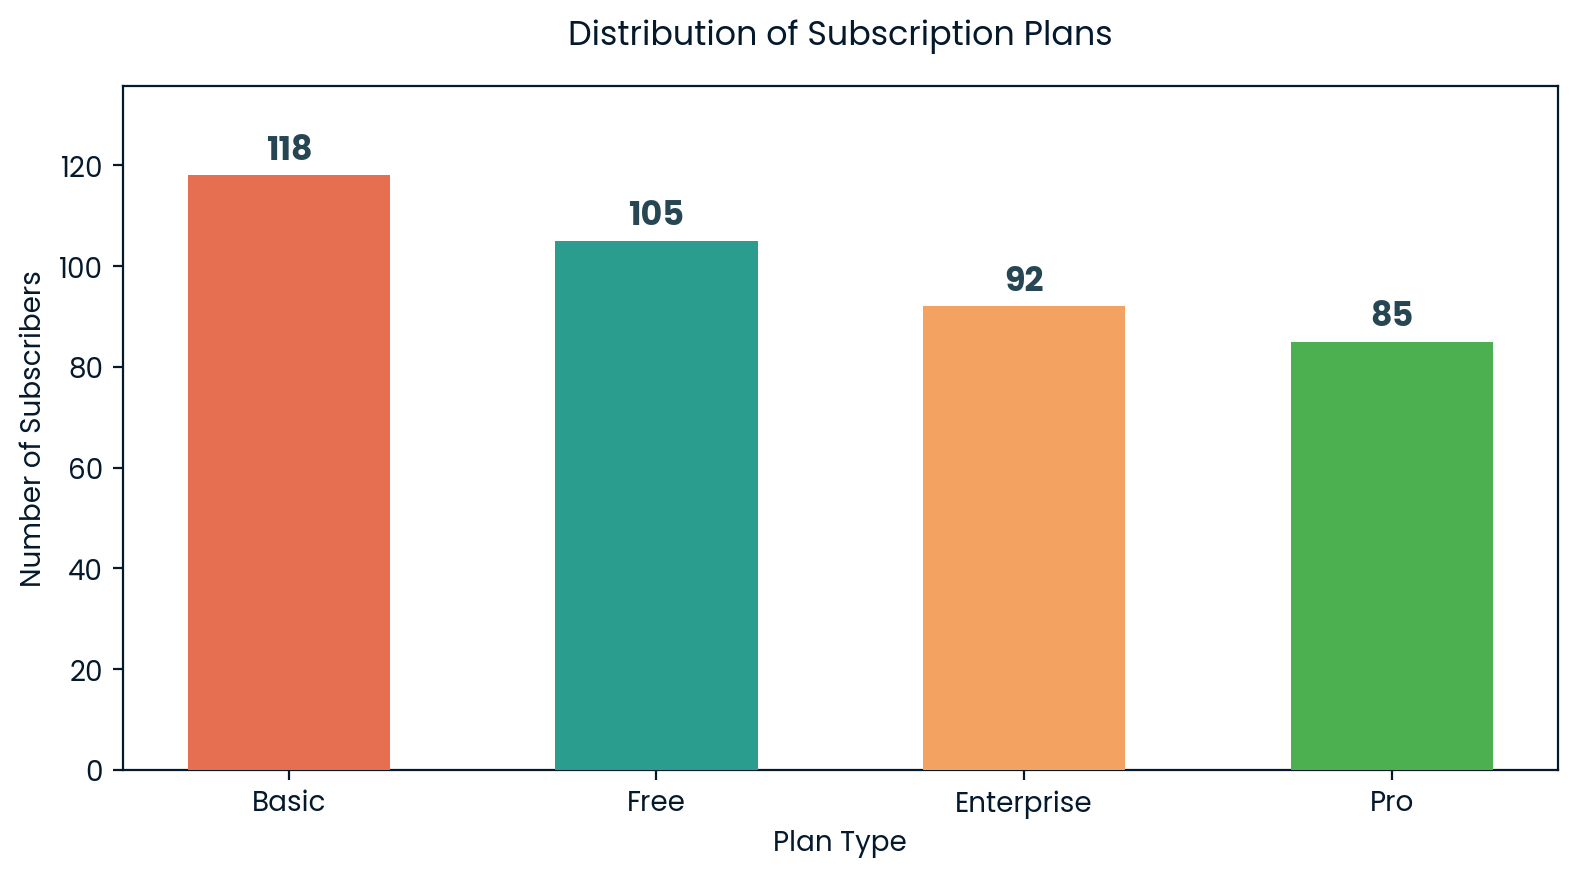


Plan counts:
Basic         118
Free          105
Enterprise     92
Pro            85
Name: plan, dtype: int64

Basic is the most common plan (118 subscribers, 29.5%).
Free is the second largest group (105 subscribers, 26.2%).


In [34]:
CORAL = '#E76F51'
TEAL = '#2A9D8F'
ORANGE = '#F4A261'
GREEN = '#4CAF50'
NAVY = '#264653'
fig, ax = plt.subplots(figsize=(8, 4.5))

plan_counts = df['plan'].value_counts()
colors = [CORAL, TEAL, ORANGE, GREEN]
bars = ax.bar(plan_counts.index, plan_counts.values, color=colors, width=0.55, zorder=3)

# Add value labels
for bar, val in zip(bars, plan_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            str(val), ha='center', va='bottom', fontsize=12, fontweight='bold', color=NAVY)

ax.set_title('Distribution of Subscription Plans', pad=15)
ax.set_xlabel('Plan Type')
ax.set_ylabel('Number of Subscribers')
ax.set_ylim(0, plan_counts.max() * 1.15)

plt.tight_layout()
plt.savefig('chart1_plan_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlan counts:")
print(plan_counts)
print(f"\nBasic is the most common plan ({plan_counts['Basic']} subscribers, {plan_counts['Basic']/len(df)*100:.1f}%).")
print(f"Free is the second largest group ({plan_counts['Free']} subscribers, {plan_counts['Free']/len(df)*100:.1f}%).")

**Finding:** Basic is the most common plan (118 subscribers, 29.5%), followed by Free (105 subscribers, 26.3%). Free users represent over a quarter of the subscriber base — a segment worth close attention given their churn behaviour.

 3.2 Single Variable: Distribution of Support Resolution Times

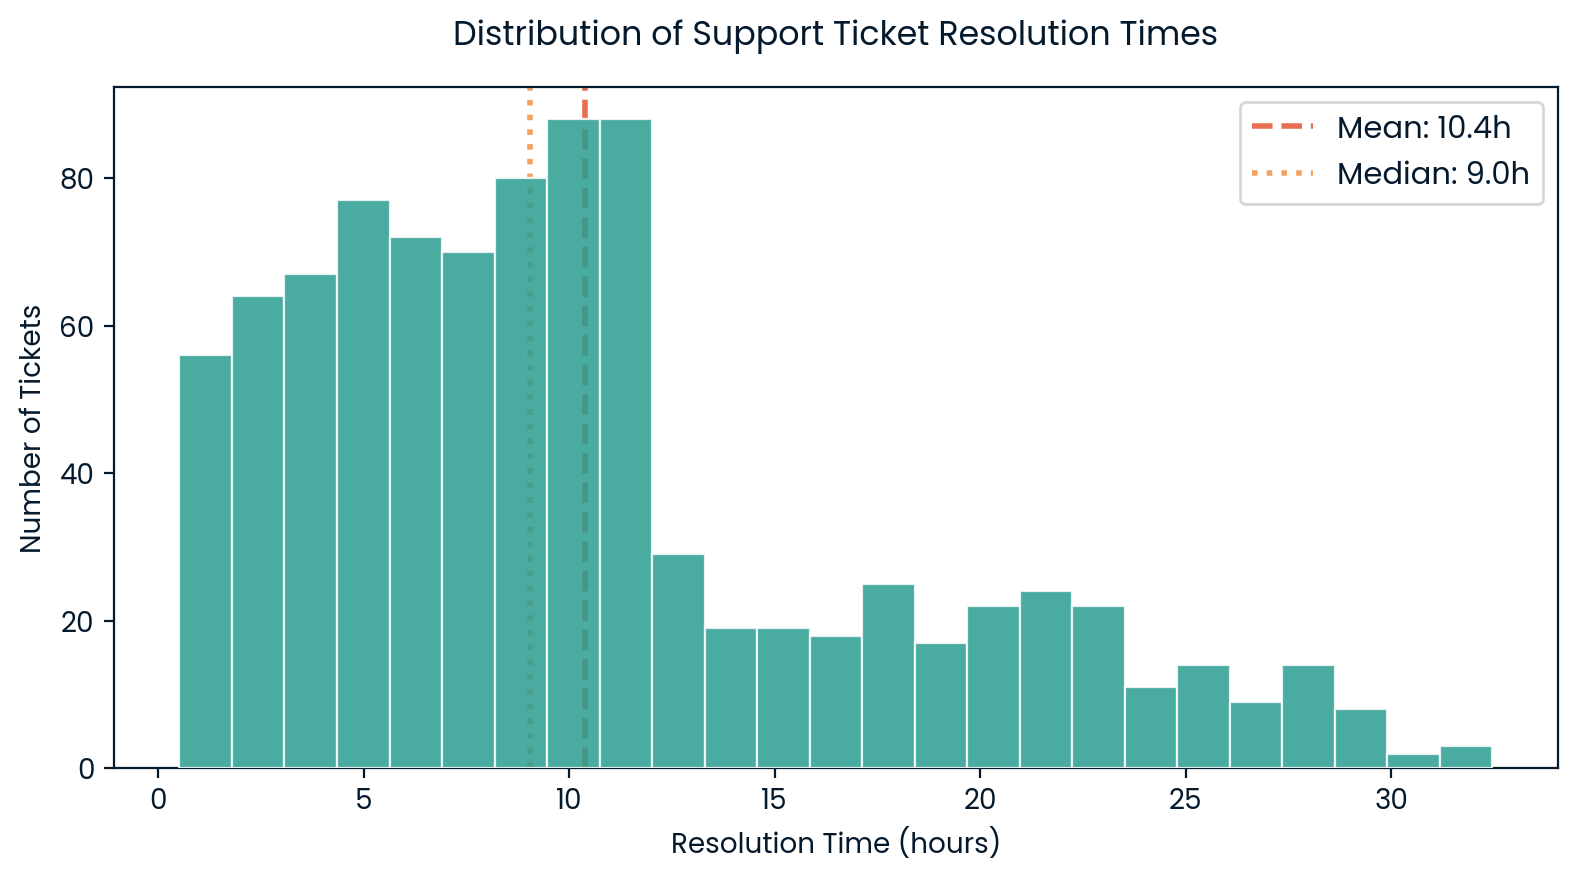

count    918.00
mean      10.39
std        7.08
min        0.52
25%        5.11
50%        9.04
75%       13.14
max       32.46
Name: resolution_time_hours, dtype: float64


In [32]:
TEAL = '#2A9D8F'
CORAL = '#E76F51'
ORANGE = '#F4A261'
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.hist(df2['resolution_time_hours'], bins=25, color=TEAL, edgecolor='white',
        linewidth=0.8, alpha=0.85, zorder=3)

ax.axvline(df2['resolution_time_hours'].mean(), color=CORAL, linewidth=2,
           linestyle='--', label=f"Mean: {df2['resolution_time_hours'].mean():.1f}h")
ax.axvline(df2['resolution_time_hours'].median(), color=ORANGE, linewidth=2,
           linestyle=':', label=f"Median: {df2['resolution_time_hours'].median():.1f}h")

ax.set_title('Distribution of Support Ticket Resolution Times', pad=15)
ax.set_xlabel('Resolution Time (hours)')
ax.set_ylabel('Number of Tickets')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('chart2_resolution_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print(df2['resolution_time_hours'].describe().round(2))

**Finding:** Most tickets are resolved within 15 hours, but the distribution is right-skewed — a tail extends to over 32 hours. The mean (10.4h) is pulled above the median (9.0h) by slow outlier resolutions. These slow cases, as we will see, are concentrated among churned users.

3.3 Multi-Variable: Churn Rate by Subscription Plan

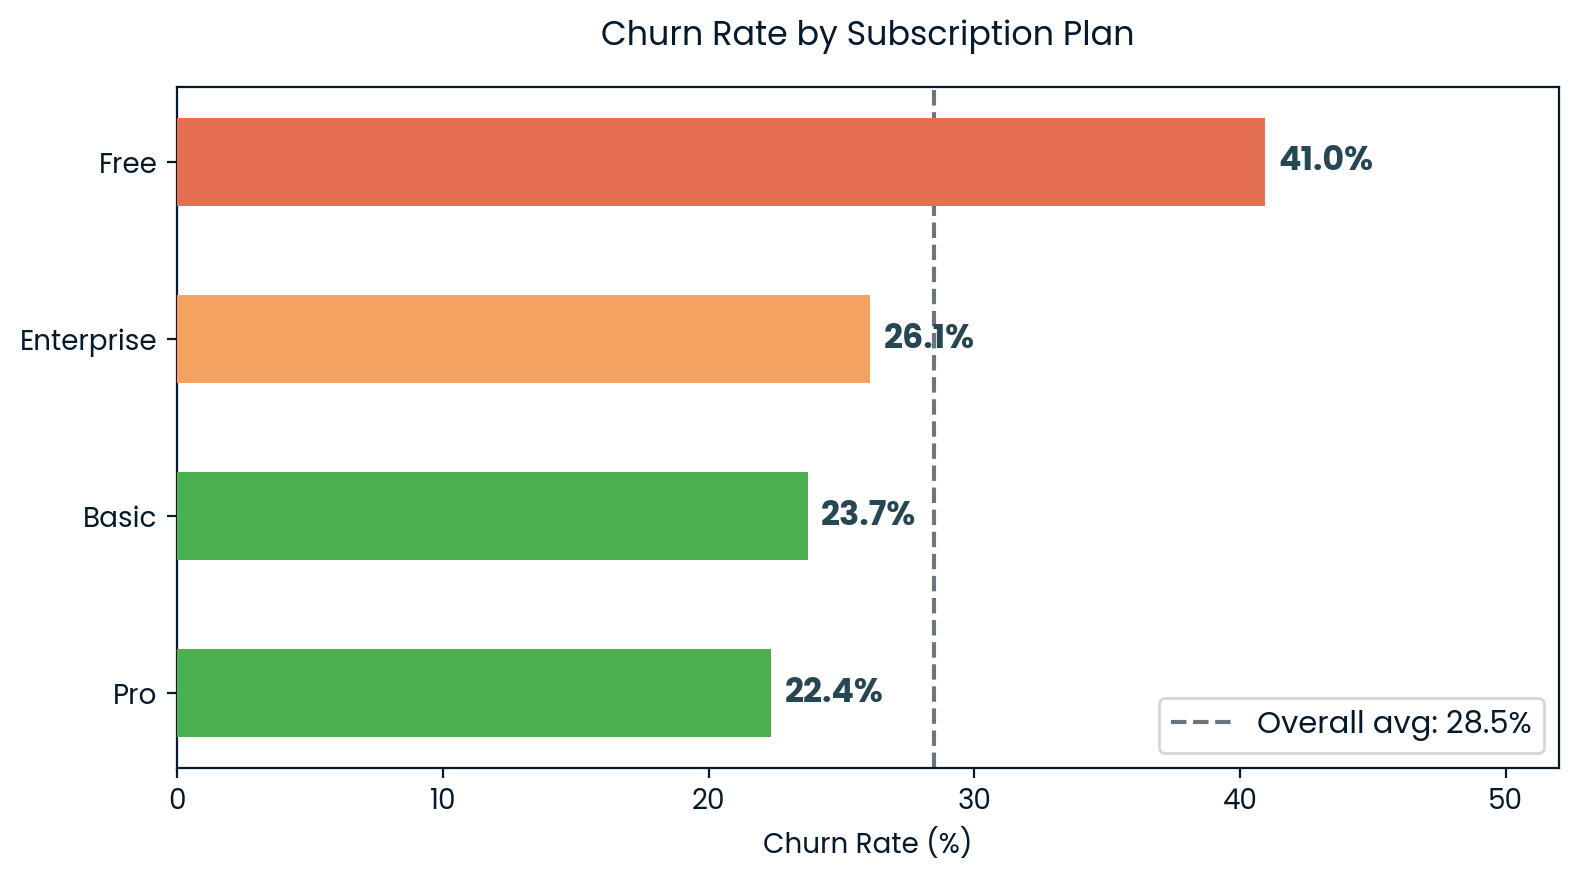

Churn rate by plan:
plan
Free          41.0
Enterprise    26.1
Basic         23.7
Pro           22.4
Name: Y, dtype: float64


In [36]:
NAVY = '#264653'
TEAL = '#2A9D8F'
GREEN = '#4CAF50'
ORANGE = '#F4A261'
CORAL = '#E76F51'
MUTED = '#6C757D'
churn_by_plan = (
    pd.crosstab(df['plan'], df['churn'], normalize='index') * 100
).sort_values('Y', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4.5))

bar_colors = [GREEN if v < 25 else ORANGE if v < 30 else CORAL
              for v in churn_by_plan['Y']]
bars = ax.barh(churn_by_plan.index, churn_by_plan['Y'],
               color=bar_colors, height=0.5, zorder=3)

for bar, val in zip(bars, churn_by_plan['Y']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=12, fontweight='bold', color=NAVY)

ax.axvline(28.5, color=MUTED, linewidth=1.5, linestyle='--', label='Overall avg: 28.5%')
ax.set_title('Churn Rate by Subscription Plan', pad=15)
ax.set_xlabel('Churn Rate (%)')
ax.set_xlim(0, 52)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('chart3_churn_by_plan.png', dpi=150, bbox_inches='tight')
plt.show()

print("Churn rate by plan:")
print(churn_by_plan['Y'].sort_values(ascending=False).round(1))

**Finding:** Free plan users churn at **41.0%** — significantly above all paid tiers. Pro users have the lowest churn at 22.4%. This 18-percentage-point gap between Free and Pro represents a major conversion opportunity: Free users who can be moved to a paid plan are far more likely to stay.

3.4 Multi-Variable: Engagement by Churn Status

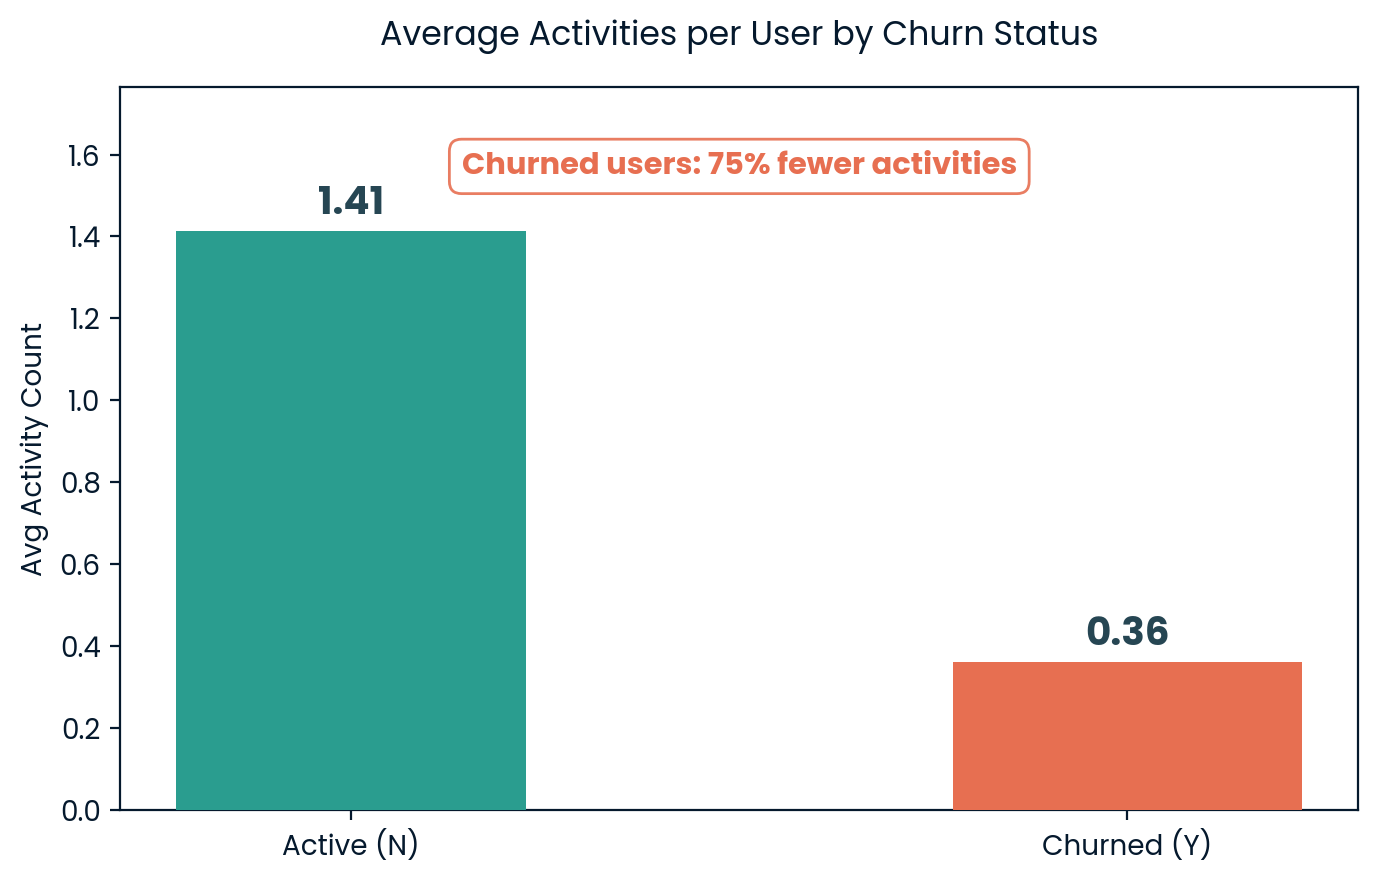

Average activities per user:
churn
N    1.413
Y    0.360
Name: activity_count, dtype: float64

Churned users perform 75% fewer activities than active users.


In [37]:
eng_by_churn = analysis.groupby('churn')['activity_count'].mean()

fig, ax = plt.subplots(figsize=(7, 4.5))

bar_colors = [TEAL, CORAL]
bars = ax.bar(['Active (N)', 'Churned (Y)'], eng_by_churn.values,
              color=bar_colors, width=0.45, zorder=3)

for bar, val in zip(bars, eng_by_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', va='bottom', fontsize=14,
            fontweight='bold', color=NAVY)

ax.set_title('Average Activities per User by Churn Status', pad=15)
ax.set_ylabel('Avg Activity Count')
ax.set_ylim(0, eng_by_churn.max() * 1.25)

pct_drop = (1 - eng_by_churn['Y'] / eng_by_churn['N']) * 100
ax.text(0.5, 0.88, f'Churned users: {pct_drop:.0f}% fewer activities',
        transform=ax.transAxes, ha='center', fontsize=11,
        color=CORAL, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=CORAL, alpha=0.9))

plt.tight_layout()
plt.savefig('chart4_engagement_by_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print("Average activities per user:")
print(eng_by_churn.round(3))
print(f"\nChurned users perform {pct_drop:.0f}% fewer activities than active users.")


**Finding:** This is the strongest signal in the dataset. Active users average **1.41 activities**, while churned users average only **0.36** — a 74% drop. Users who are not engaging with the app (tracking workouts, watching videos, reading articles) have very little reason to maintain their subscription.

3.5 Multi-Variable: Support Resolution Time by Churn Status

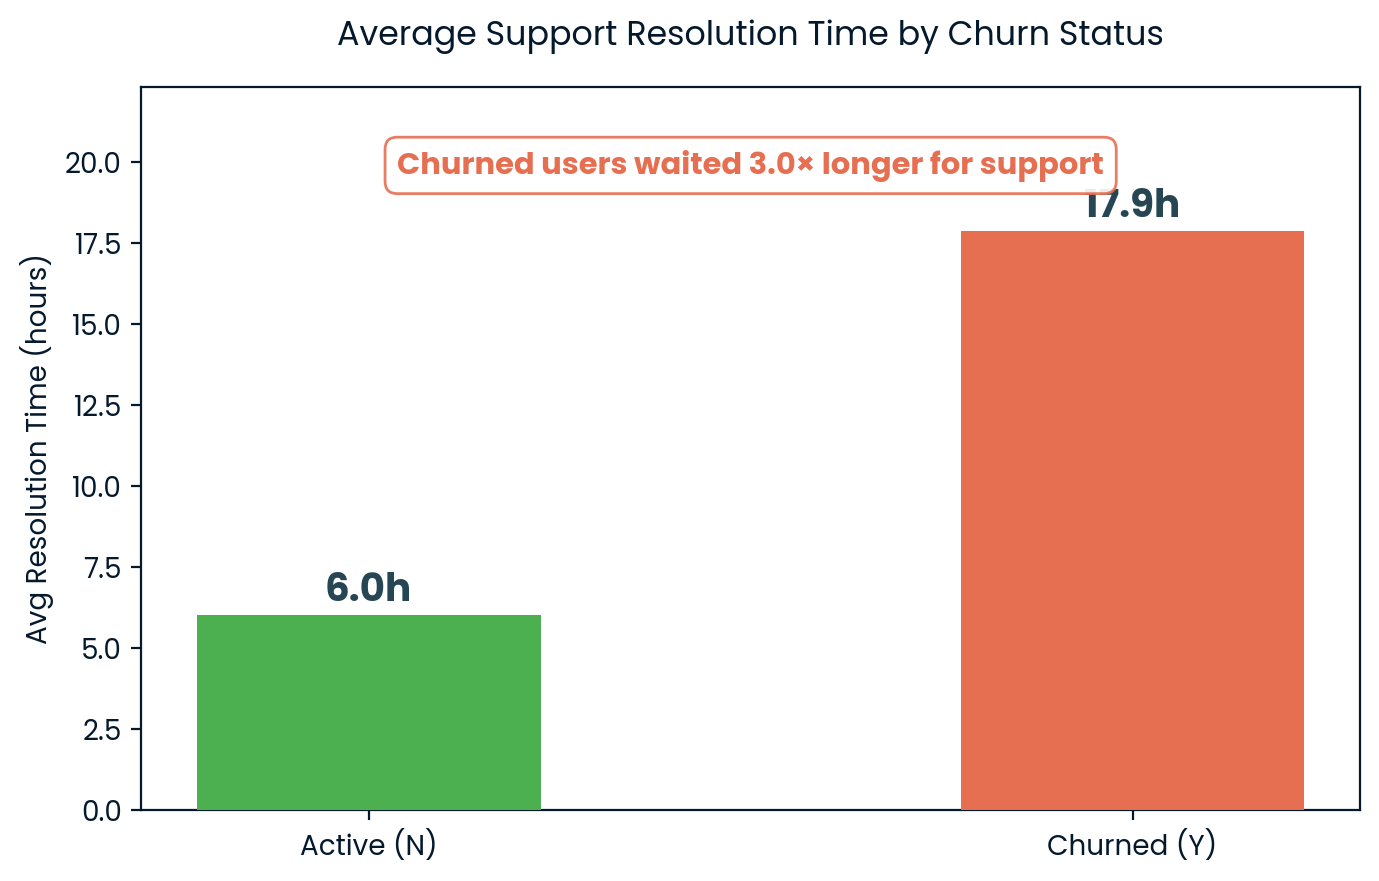

Average resolution time per user:
churn
N     6.01
Y    17.87
Name: avg_resolution_time, dtype: float64

Churned users waited 3.0x longer than active users for support resolution.


In [38]:
res_by_churn = analysis.groupby('churn')['avg_resolution_time'].mean()

fig, ax = plt.subplots(figsize=(7, 4.5))

bar_colors = [GREEN, CORAL]
bars = ax.bar(['Active (N)', 'Churned (Y)'], res_by_churn.values,
              color=bar_colors, width=0.45, zorder=3)

for bar, val in zip(bars, res_by_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f'{val:.1f}h', ha='center', va='bottom', fontsize=14,
            fontweight='bold', color=NAVY)

ax.set_title('Average Support Resolution Time by Churn Status', pad=15)
ax.set_ylabel('Avg Resolution Time (hours)')
ax.set_ylim(0, res_by_churn.max() * 1.25)

multiplier = res_by_churn['Y'] / res_by_churn['N']
ax.text(0.5, 0.88, f'Churned users waited {multiplier:.1f}× longer for support',
        transform=ax.transAxes, ha='center', fontsize=11,
        color=CORAL, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=CORAL, alpha=0.9))

plt.tight_layout()
plt.savefig('chart5_resolution_by_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print("Average resolution time per user:")
print(res_by_churn.round(2))
print(f"\nChurned users waited {multiplier:.1f}x longer than active users for support resolution.")


**Finding:** Churned customers experienced an average support resolution time of **17.9 hours**, compared to **6.0 hours** for active users — nearly 3× longer. Poor support responsiveness is a meaningful contributor to customer departure. This is an operationally fixable problem.

3.6 Ticket Volume by Churn Status

In [39]:
tickets_by_churn = analysis.groupby('churn')['ticket_count'].mean()
print("Average support tickets per user:")
print(tickets_by_churn.round(2))
print()
print("Churned users raised slightly more tickets, consistent with experiencing more friction.")
print("However, the resolution time difference is more significant than ticket volume.")

Average support tickets per user:
churn
N    2.23
Y    2.45
Name: ticket_count, dtype: float64

Churned users raised slightly more tickets, consistent with experiencing more friction.
However, the resolution time difference is more significant than ticket volume.


---
## 4. Business KPI Definition

### 4.1 Primary KPI: Monthly Churn Rate

**Definition:** The percentage of subscribers who cancel or do not renew in a given month.

**Formula:**
> `Churn Rate (%) = (Number of Users Who Churned / Total Subscribers at Start of Period) × 100`

**Why this metric?**  
Churn rate is the single most direct measure of the retention problem. It aggregates the effect of all underlying drivers (engagement, support quality, plan value) into one number that leadership can act on and track over time.

**Monitoring frequency:** Monthly  
**Owner:** Head of Analytics  
**Alerting threshold:** Trigger review if monthly churn exceeds 30%

In [40]:
# Current baseline churn rate
overall_churn_rate = (df['churn'] == 'Y').mean() * 100
print(f"Current Churn Rate (baseline): {overall_churn_rate:.1f}%")
print(f"Churned users: {(df['churn']=='Y').sum()} out of {len(df)} total subscribers")

Current Churn Rate (baseline): 28.5%
Churned users: 114 out of 400 total subscribers


4.2 Supporting KPIs

In [41]:
# KPI 1: Overall Churn Rate
kpi1 = (df['churn'] == 'Y').mean() * 100

# KPI 2: Average Engagement (activities per user)
kpi2 = activity_per_user['activity_count'].mean()

# KPI 3: Average Support Resolution Time (all tickets)
kpi3 = df2['resolution_time_hours'].mean()

# KPI 4: Free Plan Churn Rate
free_churn = (df[df['plan']=='Free']['churn']=='Y').mean() * 100

print("=" * 55)
print(f"{'KPI':<35} {'Current':>8}  {'Target':>8}")
print("=" * 55)
print(f"{'Monthly Churn Rate':<35} {kpi1:>7.1f}%  {'< 20%':>8}")
print(f"{'Avg Engagement (activities/user)':<35} {kpi2:>8.2f}  {'> 3.0':>8}")
print(f"{'Avg Support Resolution Time (hrs)':<35} {kpi3:>8.1f}  {'< 6h':>8}")
print(f"{'Free Plan Churn Rate':<35} {free_churn:>7.1f}%  {'< 30%':>8}")
print("=" * 55)

KPI                                  Current    Target
Monthly Churn Rate                     28.5%     < 20%
Avg Engagement (activities/user)        1.81     > 3.0
Avg Support Resolution Time (hrs)       10.4      < 6h
Free Plan Churn Rate                   41.0%     < 30%


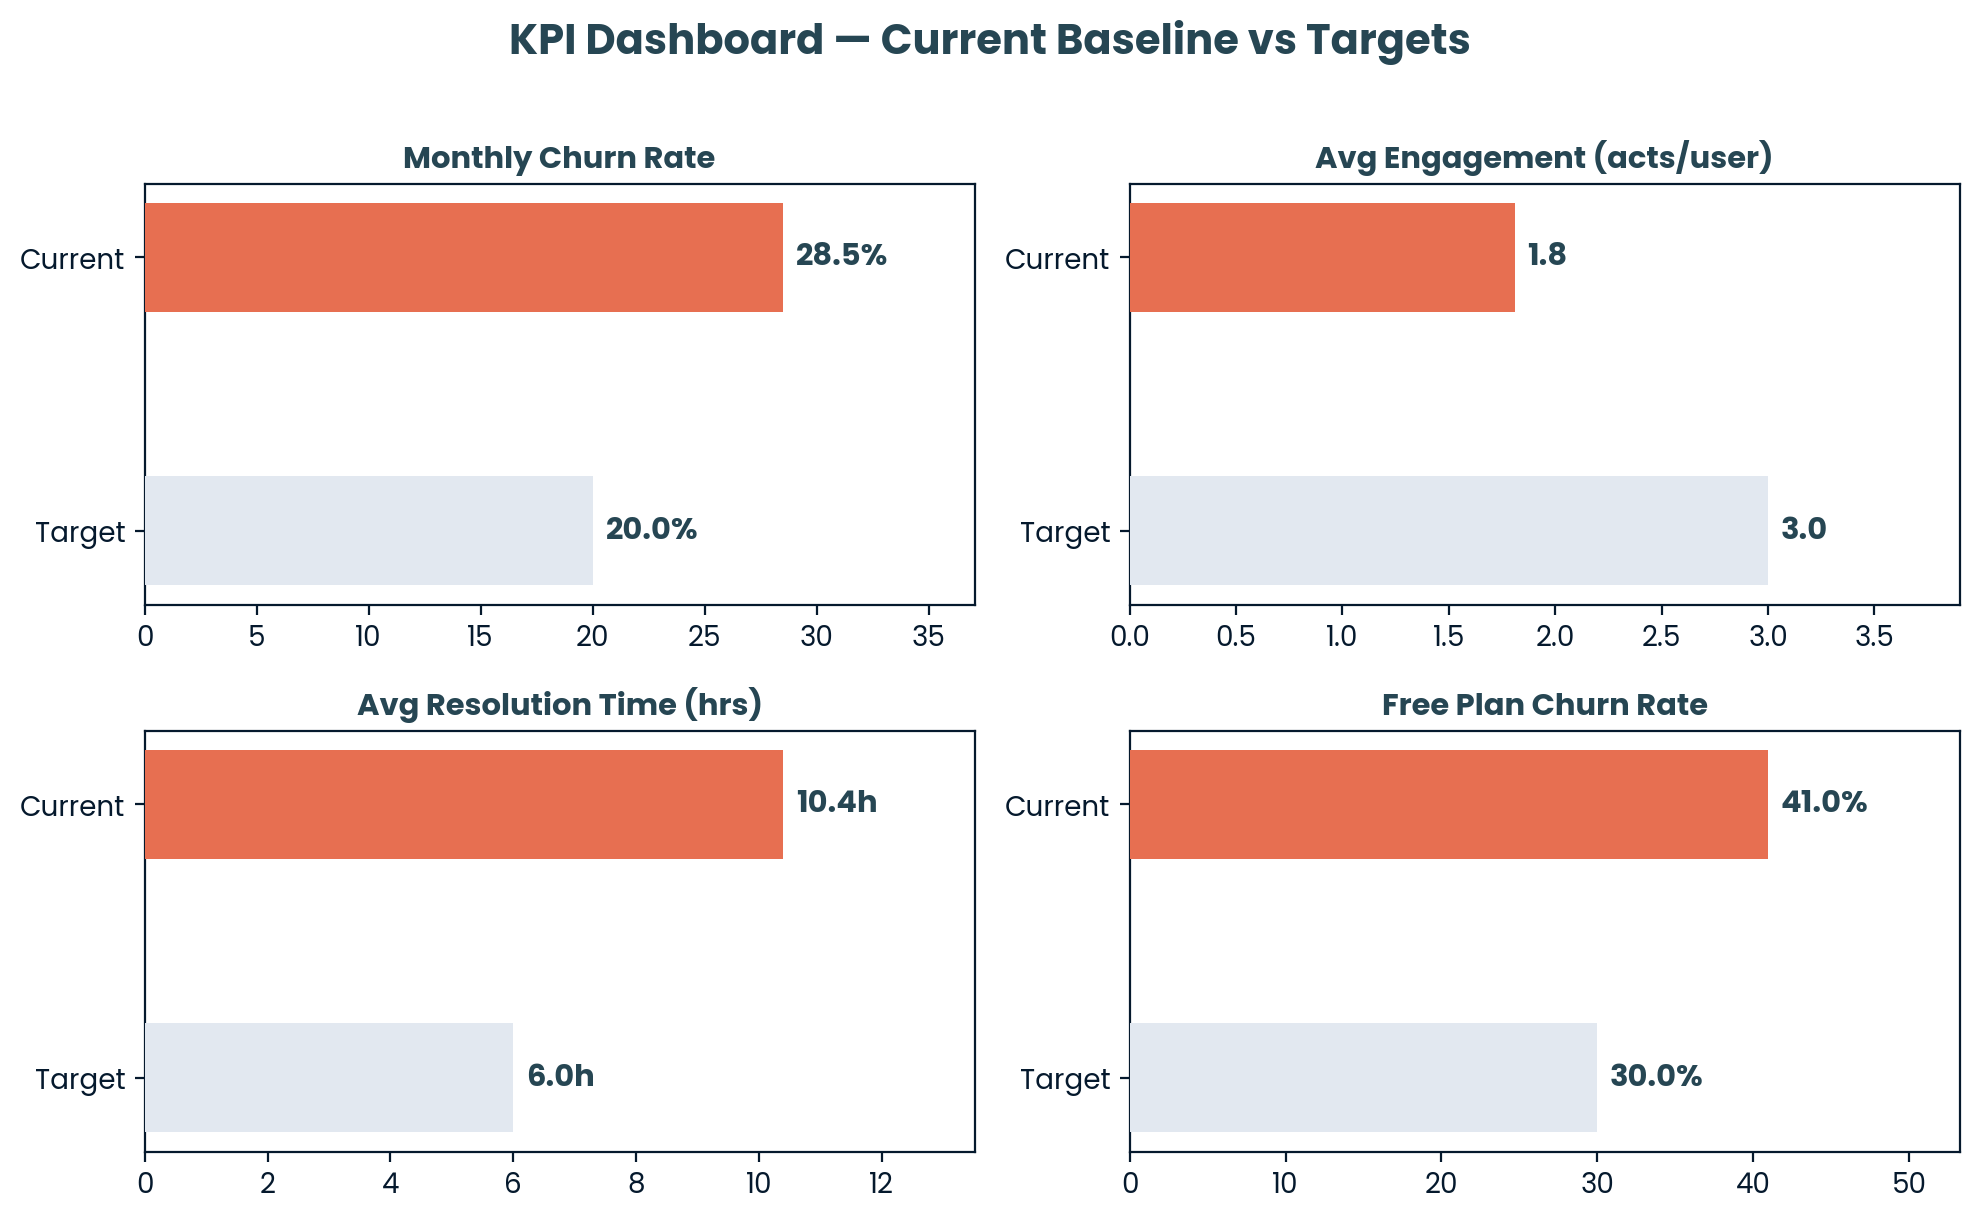

In [42]:
# KPI Dashboard visualisation
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
fig.suptitle('KPI Dashboard — Current Baseline vs Targets', fontsize=15,
             fontweight='bold', color=NAVY, y=1.01)

kpi_data = [
    ('Monthly Churn Rate', kpi1, 20, '%'),
    ('Avg Engagement (acts/user)', kpi2, 3.0, ''),
    ('Avg Resolution Time (hrs)', kpi3, 6.0, 'h'),
    ('Free Plan Churn Rate', free_churn, 30.0, '%'),
]

for ax, (label, current, target, unit) in zip(axes.flat, kpi_data):
    is_higher_bad = label != 'Avg Engagement (acts/user)'
    needs_action = (current > target) if is_higher_bad else (current < target)
    color = CORAL if needs_action else GREEN

    ax.barh(['Target', 'Current'], [target, current],
            color=['#E2E8F0', color], height=0.4, zorder=3)
    ax.set_title(label, fontsize=11, fontweight='bold', color=NAVY)
    ax.set_xlim(0, max(current, target) * 1.3)

    for i, (val, lbl) in enumerate([(target, 'Target'), (current, 'Current')]):
        ax.text(val + max(current, target)*0.02, i,
                f'{val:.1f}{unit}', va='center', fontsize=11, fontweight='bold',
                color=NAVY)
    ax.set_facecolor('white')
    ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('chart6_kpi_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Summary & Recommendations

### 5.1 Key Findings

Three primary churn drivers were identified from the data:

In [43]:
print("=" * 60)
print("FINDING 1: Low Engagement is the #1 Churn Predictor")
print("=" * 60)
print(f"  Active users avg activities:  {eng_by_churn['N']:.2f}")
print(f"  Churned users avg activities: {eng_by_churn['Y']:.2f}")
print(f"  Difference: {(1 - eng_by_churn['Y']/eng_by_churn['N'])*100:.0f}% fewer activities among churned users")
print()

print("=" * 60)
print("FINDING 2: Slow Support Drives Churn")
print("=" * 60)
print(f"  Active users avg resolution:  {res_by_churn['N']:.2f} hours")
print(f"  Churned users avg resolution: {res_by_churn['Y']:.2f} hours")
print(f"  Churned users waited {res_by_churn['Y']/res_by_churn['N']:.1f}x longer")
print()

print("=" * 60)
print("FINDING 3: Free Plan Has Highest Churn Risk")
print("=" * 60)
churn_rates = (pd.crosstab(df['plan'], df['churn'], normalize='index')*100)['Y']
for plan, rate in churn_rates.sort_values(ascending=False).items():
    print(f"  {plan:<12}: {rate:.1f}% churn rate")

FINDING 1: Low Engagement is the #1 Churn Predictor
  Active users avg activities:  1.41
  Churned users avg activities: 0.36
  Difference: 75% fewer activities among churned users

FINDING 2: Slow Support Drives Churn
  Active users avg resolution:  6.01 hours
  Churned users avg resolution: 17.87 hours
  Churned users waited 3.0x longer

FINDING 3: Free Plan Has Highest Churn Risk
  Free        : 41.0% churn rate
  Enterprise  : 26.1% churn rate
  Basic       : 23.7% churn rate
  Pro         : 22.4% churn rate


### 5.2 Recommendations

Based on the analysis, the following actions are recommended for the next quarter:

---

**🔴 HIGH PRIORITY**

**1. Launch Re-engagement Campaigns**  
Identify users with zero activity in the past 30 days. Send personalised nudges via push notification, email, and in-app messaging. Tailor by plan type. Target: double the average activity rate from 1.81 to 3.0+. This directly addresses the strongest churn predictor.

**2. Reduce Support Resolution Time to Under 6 Hours**  
Set SLA targets: first response within 2 hours, full resolution within 6 hours. Review current staffing capacity and consider automation for common topics (billing, account). The 3× gap between active and churned users' resolution times is operationally fixable and has direct retention impact.

**3. Convert Free Users with Upgrade Incentives**  
Free plan users churn at 41% — nearly double Pro users. Offer time-limited discounts (e.g., 50% off first 3 months of Basic) to Free users who have been on the platform 30+ days. Converting 20% of Free users to paid tiers would reduce overall churn by approximately 4 percentage points.

---

**🟡 MEDIUM PRIORITY**

**4. Build an Early-Warning Churn Dashboard**  
Operationalise the findings: flag users each week who show declining activity AND long resolution times as "at-risk." Automate weekly alerts to Customer Success for proactive outreach before these users decide to cancel.

**5. Introduce Structured Onboarding for New Users**  
Many churned users show low engagement from day one. A guided onboarding flow — first workout tracked, first article read, first video watched — can establish habit loops early and significantly improve 30-day retention.

---

### 5.3 Conclusion

Fit.ly Tech is currently losing **28.5% of its subscriber base** to churn. The analysis of 400 subscribers across engagement, support, and plan-type dimensions reveals three clear, actionable drivers. The five recommendations above can be initiated within the next quarter and are expected to bring monthly churn below 20% within two quarters if implemented consistently.

Monthly tracking of the four KPIs defined in Section 4 will allow leadership to measure progress and course-correct quickly.


## ✅ When you have finished...
-  Publish your Workspace using the option on the left
-  Check the published version of your report:
	-  Can you see everything you want us to grade?
    -  Are all the graphics visible?
-  Review the grading rubric. Have you included everything that will be graded?
-  Head back to the [Certification Dashboard](https://app.datacamp.com/certification) to submit your practical exam report and record your presentation